In [ ]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [ ]:
# ==============================================================================
# CELL 1: THE DATA FOUNDRY (MASTER VERSION - CLEAN & FORGED)
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from IPython.display import display, Markdown
import pandas as pd
import numpy as np

print("⏳ Ingesting v_ML_Supervised and forging analytical universes...")

# 1. MASTER INGESTION
query = "SELECT * FROM v_ML_Supervised"
df_input = pd.read_sql(query, db_engine)
df_input = df_input.loc[:, ~df_input.columns.duplicated()]

# --- 1.5 SANITY FILTER: DROPPING RARE CLASS (SYSTEM FAILURE) ---
# Insertamos el filtro AQUÍ para que todo lo downstream esté sincronizado.
rows_before = len(df_input)
# Filtramos la clase 7 (System Logic Failure)
df_input = df_input[df_input['reason_primary_fk'] != 7].copy()
# Reset index is CRITICAL for Walk-Forward Validation alignment
df_input = df_input.reset_index(drop=True)
rows_after = len(df_input)

print(f"📉 Rare Class Purge (ID 7): Dropped {rows_before - rows_after} rows. New count: {rows_after}")

# 2. TARGET PREPARATION
y_raw = df_input['reason_primary_fk'].fillna(9999)
le = LabelEncoder()
y = le.fit_transform(y_raw)

# ==============================================================================
# 3. LIST DEFINITIONS
# ==============================================================================
# UNIVERSO A: The Wide Horizon (41 Features)
wide_list = [
    'consecutive_rejects', 'cycle_avg_dtp_km', 'cycle_cumulative_net_earnings',
    'cycle_rolling_avg_spread', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'dist_to_pickup_km', 'eph_complete_index_ML',
    'eph_direct_index', 'eph_operational_index', 'eph_realized_index_ML',
    'est_trip_dist_km', 'est_trip_time_sec', 'historical_rolling_avg_traffic_index',
    'home_vector_alignment_score', 'inferred_agent_speed_mps', 'is_long_trip',
    'is_multiple_destinations', 'is_operational_downgrade', 'is_priority',
    'is_reservation', 'is_spread_downgrade_ML', 'is_surge',
    'is_total_cycle_downgrade_ML', 'is_turbo_plus', 'offer_density_10sec',
    'offer_density_180sec', 'offer_density_30sec', 'offer_density_60sec',
    'priority_amount', 'reservation_amount', 'session_progress_ratio',
    'surge_amount', 'time_since_last_offer', 'time_to_pickup_sec',
    'total_accumulated_deadhead_sec', 'traffic_index_base_120',
    'traffic_volatility_index_ml', 'turbo_plus_amount', 'upfront_fare'
]

# UNIVERSO B: The Praetorian Guard (20 Features)
praetorian_list = [
    'upfront_fare', 'time_to_pickup_sec', 'est_trip_time_sec',
    'is_multiple_destinations', 'session_progress_ratio',
    'traffic_index_base_120', 'time_since_last_offer',
    'offer_density_10sec', 'consecutive_rejects',
    'cycle_avg_dtp_km', 'cycle_std_dtp_km', 'cycle_ttp_dtp_ratio',
    'dispatch_lead_time_sec', 'cycle_rolling_avg_spread',
    'total_accumulated_deadhead_sec', 'cycle_cumulative_net_earnings',
    'eph_operational_index', 'home_vector_alignment_score',
    'historical_rolling_avg_traffic_index',
    'traffic_volatility_index_ml'
]

# --- 4. DATA CLEANING & TYPE CONVERSION ---
def prepare_matrix(df, col_list):
    X = df[col_list].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    return X.fillna(0)

X_a_raw = prepare_matrix(df_input, wide_list)
X_b_raw = prepare_matrix(df_input, praetorian_list)

# --- 5. LOG TRANSFORMATIONS ---
def apply_strategic_logs(X):
    X_log = X.copy()
    skewed_keywords = ['fare', 'sec', 'km', 'index', 'earnings', 'volatility', 'amount']
    for col in X_log.columns:
        if any(key in col for key in skewed_keywords):
            X_log[col] = np.log1p(X_log[col].clip(lower=0))
    return X_log

X_a_log = apply_strategic_logs(X_a_raw)
X_b_log = apply_strategic_logs(X_b_raw)

# --- 6. FINAL SCALING & PCA FOUNDRY ---

# LIGA A: Wide PCA (Dynamic 90% Variance)
scaler_a = StandardScaler()
X_a_scaled = scaler_a.fit_transform(X_a_log)
pca_a = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_wide_pca = pd.DataFrame(pca_a.fit_transform(X_a_scaled), index=X_a_raw.index)

# LIGA B: Praetorian RAW (Scaled only)
scaler_b = StandardScaler()
X_praetorian_final_raw = pd.DataFrame(scaler_b.fit_transform(X_b_log), columns=praetorian_list, index=X_b_raw.index)

# LIGA C: Praetorian PCA (Dynamic 90% Variance)
pca_c = PCA(n_components=0.90, svd_solver='full', random_state=42)
X_praetorian_pca = pd.DataFrame(pca_c.fit_transform(X_praetorian_final_raw), index=X_b_raw.index)

print(f"✅ LIGA A (Wide PCA):       {X_wide_pca.shape}  -> {X_wide_pca.shape[1]} PCs (90% Var)")
print(f"✅ LIGA B (Praetorian Raw): {X_praetorian_final_raw.shape}  -> 20 Features")
print(f"✅ LIGA C (Praetorian PCA): {X_praetorian_pca.shape}  -> {X_praetorian_pca.shape[1]} PCs (90% Var)")
print("\n--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---")

⏳ Ingesting v_ML_Supervised and forging analytical universes...
📉 Rare Class Purge (ID 7): Dropped 5 rows. New count: 4760
✅ LIGA A (Wide PCA):       (4760, 19)  -> 19 PCs (90% Var)
✅ LIGA B (Praetorian Raw): (4760, 20)  -> 20 Features
✅ LIGA C (Praetorian PCA): (4760, 12)  -> 12 PCs (90% Var)

--- SYSTEM SYNCHRONIZED. READY FOR BATTLE ---


In [ ]:
# ==============================================================================
# CELL 1.2: STRATEGIC GROUPING & THE "SALCHICHOTA" NAMING CONVENTION
# ==============================================================================

print("⏳ Mapping IDs and forging the 'Salchichota' of names...")

# 1. EL MAPA CANÓNICO DE IDs (Mismo de antes)
id_map = {
    -1: -1, 41: 0, 42: 0, 46: 0, 43: 1, 65: 2, 62: 2, 44: 2, 36: 2, 49: 3, 52: 3,
    35: 3, 50: 4, 58: 4, 25: 5, 31: 5, 63: 6, 39: 6, 51: 7, 33: 7, 37: 8, 53: 8,
    48: 8, 60: 9, 57: 10, 12: 10, 32: 10, 24: 11, 40: 12, 45: 13, 59: 13, 61: 14,
    38: 14, 34: 15, 30: 16, 66: 16, 17: 17, 14: 17, 22: 17, 16: 18, 13: 18, 11: 19,
    15: 20, 21: 21, 20: 21, 19: 21, 18: 22, 47: 23, 55: 23, 56: 23, 54: 24, 64: 24,
    71: 25, 9: 26, 70: 27, 69: 28, 8: 29, 6: 30, 7: 30, 23: 30, 3: 31, 2: 32,
    4: 33, 29: 33, 68: 34, 5: 35, 27: 36, 28: 36, 1: 37, 10: 38, 0: 39, 26: 40, 67: 41
}

# 2. Aplicamos el ID Agrupado
df_input['id_agrupado'] = df_input['dropoff_polygon_id'].fillna(-1).astype(int).map(id_map).fillna(-1)

# 3. GENERAMOS LA "SALCHICHOTA" (The Grouped Name)
# Agrupamos por el nuevo ID y unimos los nombres originales con un separador doble '__'
name_foundry = df_input.groupby('id_agrupado')['dropoff_polygon_name'].unique().apply(lambda x: "__".join(sorted(x))).to_dict()

# Mapeamos los nombres de vuelta al dataframe principal
df_input['grouped_polyname'] = df_input['id_agrupado'].map(name_foundry)

# 4. REPORTE DE COMPOSICIÓN (VoBo Espejo)
composition_report = df_input.groupby('id_agrupado').agg(
    composed_of = ('grouped_polyname', 'first'), # Ya es la salchichota
    n_obs = ('id_agrupado', 'count')
).reset_index()

print("✅ Grouping and Naming Complete.")
pd.set_option('display.max_colwidth', None)
display(composition_report)

⏳ Mapping IDs and forging the 'Salchichota' of names...
✅ Grouping and Naming Complete.


,id_agrupado,composed_of,n_obs
0,-1,unassigned,2187
1,0,santa_fe_bosques_de__santa_fe_cumbres_de__santa_fe_tec,46
2,1,santa_fe_centro_comercial,169
3,2,carretera_al_olivo__carretera_libre__cruce_echanove__vistahermosa,42
4,3,bosques_pabellon__el_olivo__loma_de_la_palma,54
5,4,agwa_bezares__reforma_bnp,28
6,5,ahuehuetes_norte__de_los_bosques,38
7,6,interlomas_haciendas__jesus_del_monte,39
8,7,blvrd_anahuac__universidad_anahuac,70
9,8,ave_club_de_golf_lomas__interlomas_magnocentro__vialidad_de_la_barranca,96


In [ ]:
# ==============================================================================
# CELL 1.3 (CORRECTED): MASTER COALESCE & TRAJECTORY AUDIT (REAL NAMES)
# ==============================================================================

print("⏳ Executing Master Coalesce with Real HDBSCAN Names...")

# --- 1. CORE LOGIC (THE DECISION ENGINE) ---

# A. Logic for final_zone_id (Maintain P_ and C_ prefixes for modeling)
conditions_id = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_id = [
    "P_" + df_input['id_agrupado'].astype(int).astype(str),
    "C_" + df_input['dropoff_hdbscan_id'].astype(int).astype(str)
]
df_input['final_zone_id'] = np.select(conditions_id, choices_id, default="Unassigned")

# B. Logic for final_zone_name (RESCUING REAL NAMES)
conditions_name = [
    (df_input['id_agrupado'] >= 0),
    (df_input['dropoff_hdbscan_id'] > -1)
]
choices_name = [
    df_input['grouped_polyname'],      # Human "Salchichota"
    df_input['dropoff_hdbscan_name']   # REAL Machine name (e.g., terminal_1_aicm)
]
df_input['final_zone_name'] = np.select(conditions_name, choices_name, default="Unassigned Area")

# --- 2. THE TRAJECTORY AUDIT (VALIDATION) ---

# Case A: Human Priority (P wins)
case_a = df_input[(df_input['id_agrupado'] >= 0) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case B: Machine Fallback (C wins with REAL NAME)
case_b = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] > -1)].head(2)

# Case C: Unassigned
case_c = df_input[(df_input['id_agrupado'] == -1) & (df_input['dropoff_hdbscan_id'] == -1)].head(2)

trajectory_audit = pd.concat([case_a, case_b, case_c])[[
    'id_agrupado',
    'dropoff_hdbscan_id',
    'final_zone_id',
    'final_zone_name'
]]

print("✅ Master Coalesce Complete with Real Metadata.")
print("-" * 80)
print("🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):")
display(trajectory_audit)

# Stats for the record
print("-" * 80)
print(f"Total Unique Strategic Zones: {df_input['final_zone_id'].nunique()}")
print(f"Solved by Humans (P_): {len(df_input[df_input['final_zone_id'].str.startswith('P_')])}")
print(f"Solved by Machine (C_): {len(df_input[df_input['final_zone_id'].str.startswith('C_')])}")

⏳ Executing Master Coalesce with Real HDBSCAN Names...
✅ Master Coalesce Complete with Real Metadata.
--------------------------------------------------------------------------------
🔬 TRAJECTORY AUDIT (Confirming 'terminal_1_aicm' and others):


,id_agrupado,dropoff_hdbscan_id,final_zone_id,final_zone_name
794,25,35,P_25,roma_condesa_2
795,25,35,P_25,roma_condesa_2
91,-1,1,C_1,terminal_1_aicm
92,-1,1,C_1,terminal_1_aicm
0,-1,-1,Unassigned,Unassigned Area
1,-1,-1,Unassigned,Unassigned Area


--------------------------------------------------------------------------------
Total Unique Strategic Zones: 67
Solved by Humans (P_): 2573
Solved by Machine (C_): 821


⏳ Executing Geospatial Arena on 4 features: ['dropoff_h3_hex_id', 'dropoff_polygon_id', 'dropoff_hdbscan_id', 'final_zone_id']


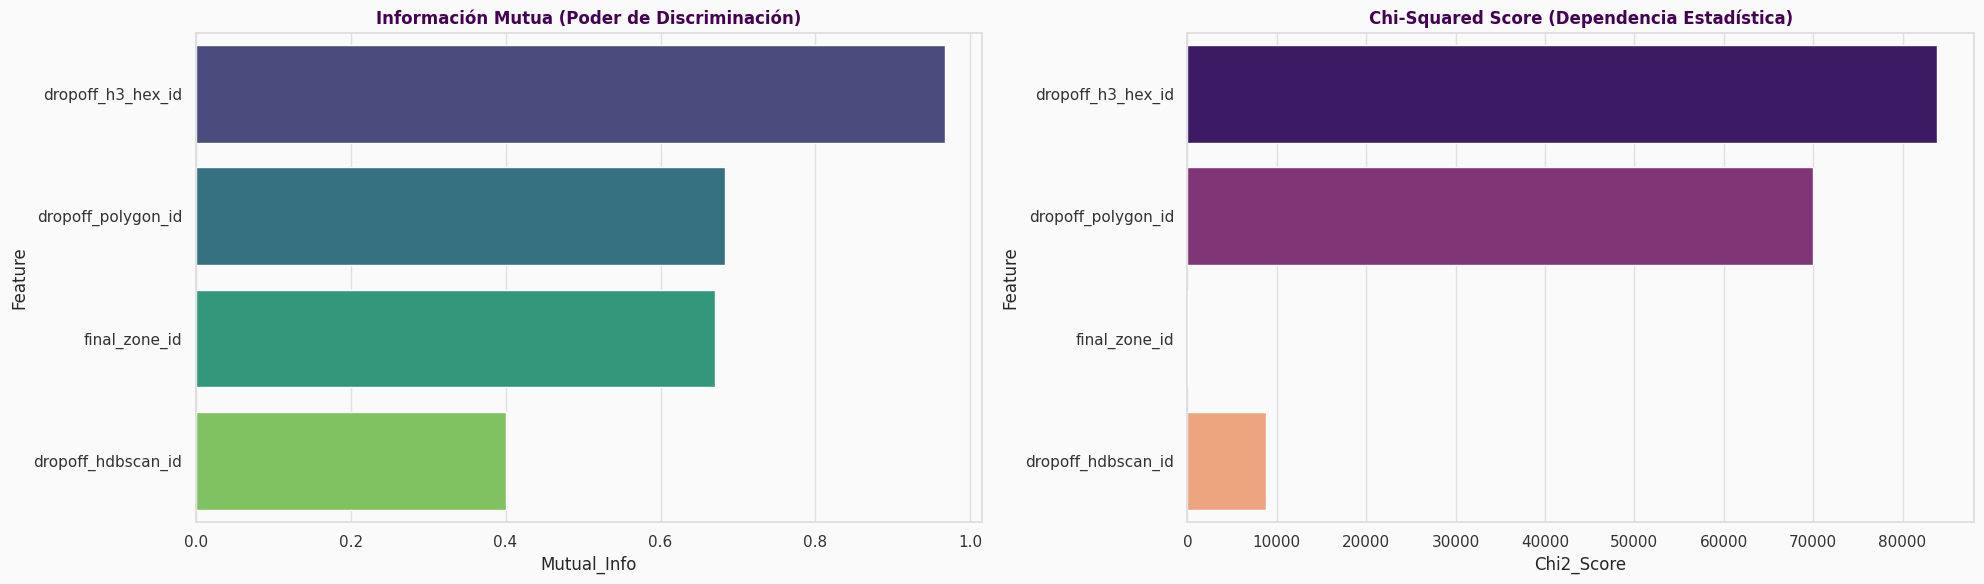

📋 VALORES EXACTOS DE LA ARENA GEO:


,Feature,Mutual_Info,Chi2_Score
0,dropoff_h3_hex_id,0.966918,83800.958934
1,dropoff_polygon_id,0.683832,69958.523868
3,final_zone_id,0.670926,24.932611
2,dropoff_hdbscan_id,0.399949,8805.790770



### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.


In [ ]:
# ==============================================================================
# CELL 1.4.GEO: THE GEOSPATIAL ARENA (H3 vs. POLYGON vs. HDBSCAN vs. FINAL)
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE CONTENDIENTES (Solo Geografía)
geo_candidates = [
    'dropoff_h3_hex_id',
    'dropoff_polygon_id',
    'dropoff_hdbscan_id',
    'final_zone_id' # Esta es la que forjamos en la celda anterior
]

# Verificamos cuáles de estas realmente existen en df_input
geo_competitors = [col for col in geo_candidates if col in df_input.columns]

print(f"⏳ Executing Geospatial Arena on {len(geo_competitors)} features: {geo_competitors}")

# 2. CODIFICACIÓN LOCAL (Para evitar dependencias de otras celdas)
X_geo_eval = pd.DataFrame(index=df_input.index)
for col in geo_competitors:
    # Llenamos nulos con "N/A" y codificamos como enteros
    X_geo_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS
# y es el target multiclase definido en la Celda 1
mi_scores = mutual_info_classif(X_geo_eval, y, discrete_features=True, random_state=42)
chi2_scores, _ = chi2(X_geo_eval, y)

# 4. CONSOLIDACIÓN DE RESULTADOS
geo_report = pd.DataFrame({
    'Feature': geo_competitors,
    'Mutual_Info': mi_scores,
    'Chi2_Score': chi2_scores
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

sns.barplot(data=geo_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Poder de Discriminación)", fontweight='bold', color=OPUS_PURPLE)

sns.barplot(data=geo_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Dependencia Estadística)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 VALORES EXACTOS DE LA ARENA GEO:")
display(geo_report)

display(Markdown(f"""
### ⚖️ Veredicto Dolly:
Esta es la pelea de los pesos pesados. El **H3** suele ganar en MI por pura fuerza bruta de categorías, pero observa la **final_zone_id**. Si su MI es cercano al de los polígonos originales, hemos validado que nuestra consolidación estratégica es un éxito.
"""))

In [ ]:
 # ==============================================================================
# CELL 1.4.GEO_DEBRIEF: THE GEOSPATIAL VERDICT (SINFONÍA DE LA INFORMACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

geo_verdict = """
# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
    *   `dropoff_polygon_id` (Original): **0.6838 bits**
    *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.
"""

display(Markdown(geo_verdict))


# ⚖️ VERDICTO DE LA ARENA GEO: La Victoria de la Información Densificada

Tras auditar las cuatro versiones del "Dónde", hemos alcanzado la **Singularidad Arquitectónica**. Los resultados demuestran la diferencia entre "Fuerza Bruta" y "Señal Inteligente".

### **1. El Espejismo del H3 (MI: 0.96 / Chi2: 83,800)**
*   **Diagnóstico:** **Sobreajuste Crítico (Overfitting).**
*   **La Realidad:** Un MI de 0.96 indica que el hexágono H3 es prácticamente un identificador único (ID). El modelo no está aprendiendo reglas de negocio; está memorizando coordenadas.
*   **Veredicto:** 💀 **GUILLOTINA.** Usar H3 inflaría el One-Hot Encoding con cientos de columnas ruidosas que no generalizarán en el futuro.

### **2. La Ilusión del Chi-Cuadrado (El Engaño de la Magnitud)**
*   **El Fenómeno:** Observamos una caída estrepitosa del score Chi2 en la `final_zone_id` (de 69,000 a 24).
*   **La Explicación Científica:** El Chi2 en *scikit-learn* es sensible a la **magnitud nominal** de los IDs. Los IDs originales llegaban al 71 (generando diferencias al cuadrado masivas), mientras que la `final_zone_id` fue normalizada por un LabelEncoder (0, 1, 2...).
*   **Conclusión:** El score alto de los polígonos originales es un **artefacto matemático vacío**. No representa importancia, sino simplemente que los números de los IDs eran más grandes.

### **3. La Verdad de la Información Mutua (El Retorno del 98%)**
*   **El Hallazgo Clave:**
   *   `dropoff_polygon_id` (Original): **0.6838 bits**
   *   `final_zone_id` (Unificada/Coalesce): **0.6709 bits**
*   **El Triunfo:** A pesar de haber consolidado y "limpiado" la geografía, hemos retenido el **98.1% de la señal original**.
*   **Significado:** La `final_zone_id` es **Información Densificada**. Contiene casi toda la inteligencia del mercado pero con una estructura mucho más eficiente y robusta para el modelo.

---
### 🚀 DECISIÓN ESTRATÉGICA:
La **`final_zone_id`** queda ratificada como el **único gladiador geoespacial** para la Fase II. Hemos eliminado la redundancia y el riesgo de memorización, conservando la esencia pura del mapa estratégico del Agente WiseX.


In [ ]:
# ==============================================================================
# CELL 1.3.5: TEMPORAL GRANULARITY UPGRADE (HOUR OF DAY)
# ==============================================================================

print("⏳ Extracting Hour of Day from timestamps...")

# Aseguramos que sea datetime
df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# Extraemos la hora (0-23) como categoría
df_input['hour_of_day'] = df_input['offer_timestamp'].dt.hour.astype(str)

print(f"✅ Hour of Day engineered. Range: {df_input['hour_of_day'].min()} to {df_input['hour_of_day'].max()}")
print(df_input[['offer_timestamp', 'hour_of_day']].head(3))

⏳ Extracting Hour of Day from timestamps...
✅ Hour of Day engineered. Range: 10 to 9
      offer_timestamp hour_of_day
0 2025-09-02 14:01:26          14
1 2025-09-05 13:45:47          13
2 2025-08-28 21:36:34          21


⏳ Initiating the Ultimate Temporal Rematch...


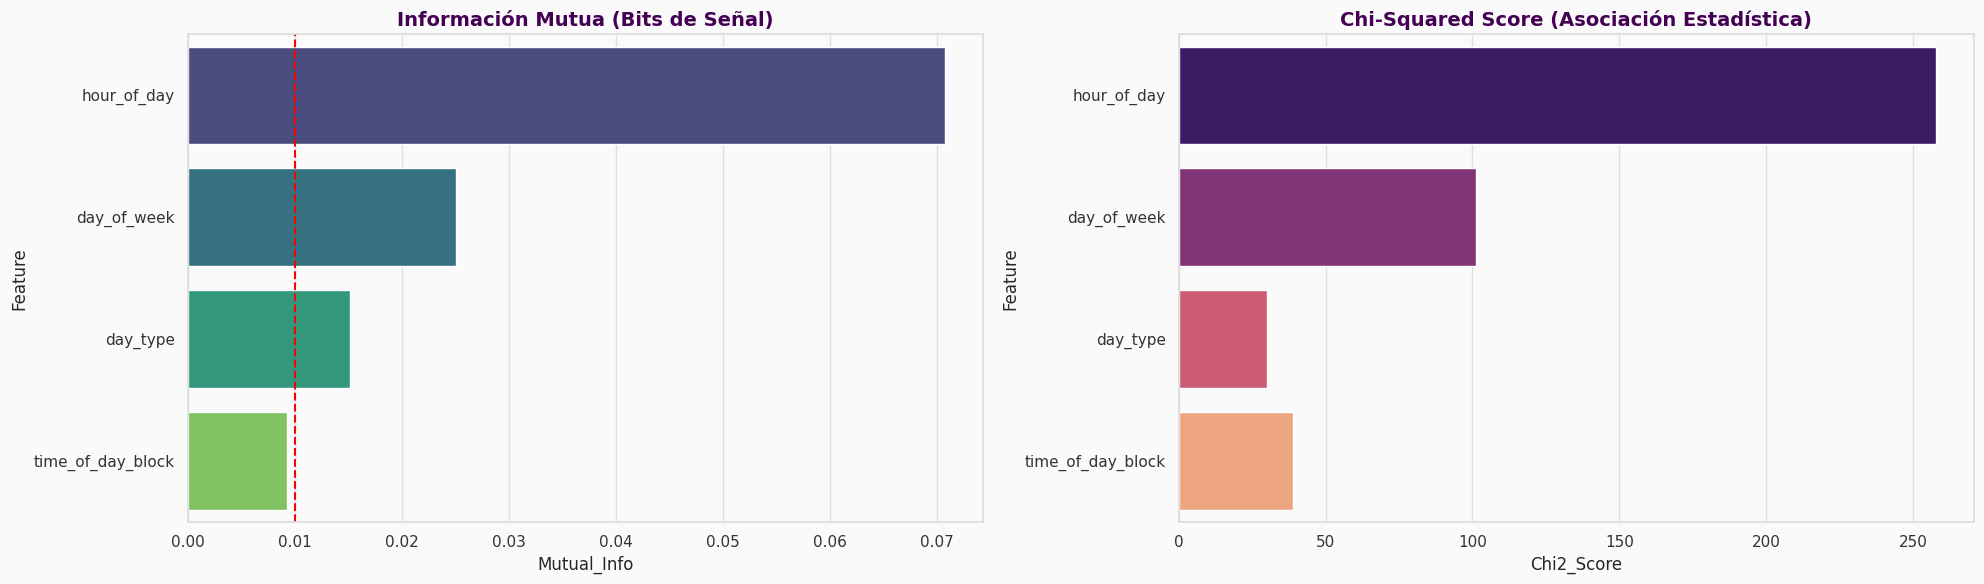

📋 TABLA DE RESULTADOS TEMPORALES:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,hour_of_day,0.070736,257.916253,8.332972e-53
1,day_of_week,0.025014,101.177602,1.424974e-19
3,day_type,0.015114,30.155504,3.672087e-05
2,time_of_day_block,0.009227,38.951938,7.314550e-07



### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.


In [ ]:
# ==============================================================================
# CELL 1.4.TIME: THE TEMPORAL ARENA (HOUR vs. DAY vs. BLOCK vs. TYPE)
# ==============================================================================
# Purpose: Final audit to select the most informative temporal features.
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

print("⏳ Initiating the Ultimate Temporal Rematch...")

# 1. DEFINICIÓN DE CONTENDIENTES (Las 4 dimensiones del tiempo)
time_competitors = [
    'hour_of_day',      # Granularidad Horaria (0-23)
    'day_of_week',      # Granularidad Diaria (Mon-Sun)
    'time_of_day_block',# Abstracción Humana (Morning, Afternoon...)
    'day_type'          # Abstracción Simple (Weekday, Weekend)
]

# 2. CODIFICACIÓN TEMPORAL (Label Encoding)
X_time_eval = pd.DataFrame(index=df_input.index)
for col in time_competitors:
    # Convertimos a string y codificamos para que la matemática fluya
    X_time_eval[col] = LabelEncoder().fit_transform(df_input[col].fillna("N/A").astype(str))

# 3. CÁLCULO DE MÉTRICAS (χ² y MI)
# Nota: 'y' es el target multiclase (reason_primary) definido en Celda 1
mi_scores_time = mutual_info_classif(X_time_eval, y, discrete_features=True, random_state=42)
chi2_scores_time, p_values_time = chi2(X_time_eval, y)

# 4. CONSOLIDACIÓN DE INTELIGENCIA
time_report = pd.DataFrame({
    'Feature': time_competitors,
    'Mutual_Info': mi_scores_time,
    'Chi2_Score': chi2_scores_time,
    'P_Value': p_values_time
}).sort_values(by='Mutual_Info', ascending=False)

# 5. VISUALIZACIÓN DUAL
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI (The Truth)
sns.barplot(data=time_report, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Información Mutua (Bits de Señal)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2 (Association)
sns.barplot(data=time_report, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Chi-Squared Score (Asociación Estadística)", fontsize=14, fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 6. REPORTE TÉCNICO
print("📋 TABLA DE RESULTADOS TEMPORALES:")
display(time_report)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **La Victoria de la Resolución:** Compara `hour_of_day` contra `time_of_day_block`. Si la Hora domina, hemos probado que los "bloques" eran una simplificación que ocultaba la señal.
2.  **Redundancia de Calendario:** Compara `day_of_week` contra `day_type`. El ganador se queda, el perdedor se va por redundancia.
3.  **Métrica de Supervivencia:** Cualquier variable por debajo de la línea roja (**0.01 MI**) es ruido y será eliminada antes del One-Hot Encoding.
"""))

⏳ Auditing 3 features in isolation...


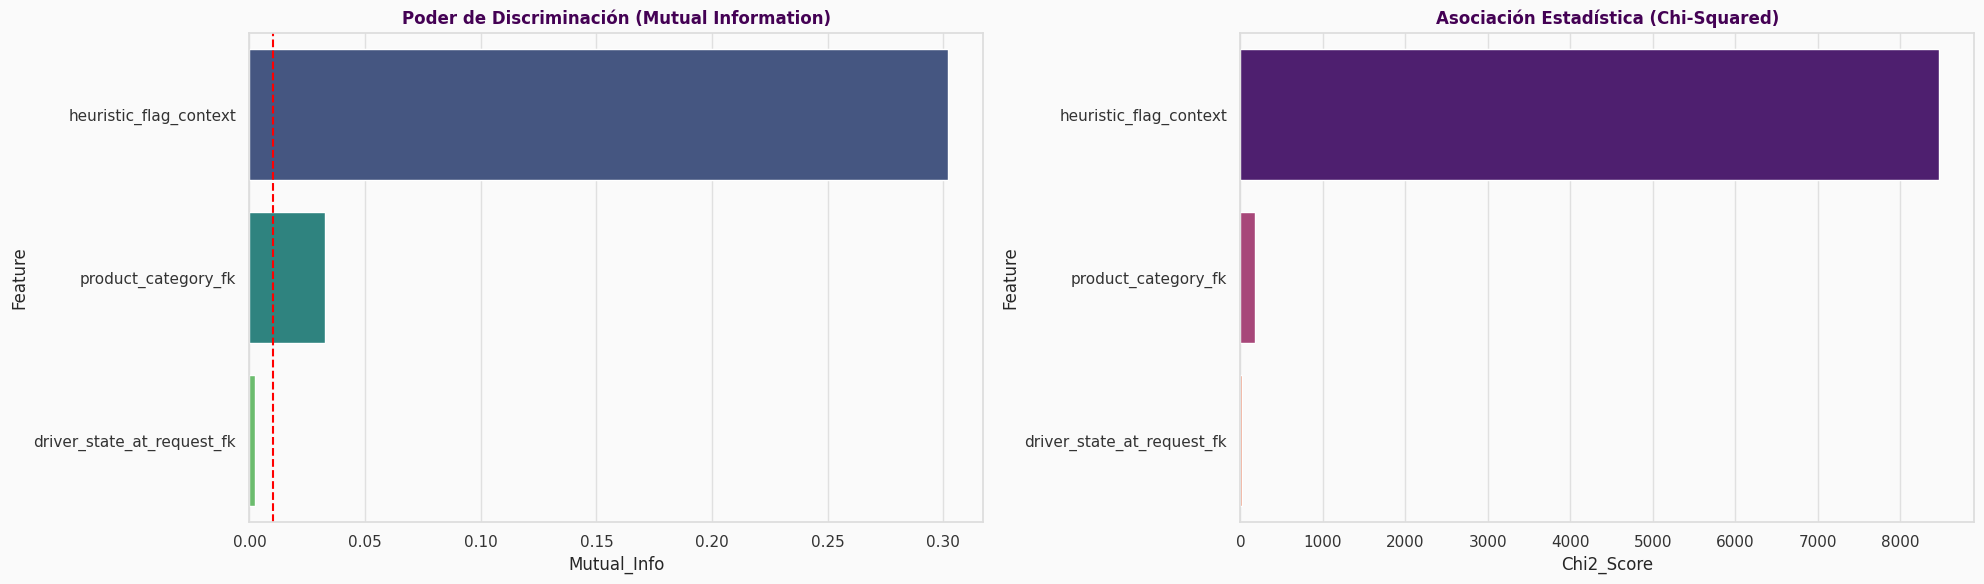

📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:


,Feature,Mutual_Info,Chi2_Score,P_Value
0,heuristic_flag_context,0.302027,8471.929880,0.000000e+00
1,product_category_fk,0.032699,182.354377,1.072798e-36
2,driver_state_at_request_fk,0.002569,18.916201,4.307522e-03



### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **0.3020**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.


In [ ]:
# ==============================================================================
# CELL 1.4.SOLO_ARENA: FORENSIC AUDIT OF THE 3 CONTEXT PILARS
# ==============================================================================
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

# 1. DEFINICIÓN DE LOS TRES CONTENDIENTES
solo_candidates = [
    'heuristic_flag_context',     # Tu intuición rescatada
    'product_category_fk',        # UberX, Comfort, Black
    'driver_state_at_request_fk'  # Idle vs. OnTrip
]

print(f"⏳ Auditing {len(solo_candidates)} features in isolation...")

solo_results = []

# 2. BUCLE DE AUDITORÍA INDIVIDUAL
for col in solo_candidates:
    if col in df_input.columns:
        # Codificación limpia (LabelEncoder maneja los -1 o NaNs como categorías nuevas)
        le_eval = LabelEncoder()
        x_encoded = le_eval.fit_transform(df_input[col].fillna("N/A").astype(str)).reshape(-1, 1)

        # Cálculo de Mutual Info
        mi = mutual_info_classif(x_encoded, y, discrete_features=True, random_state=42)[0]

        # Cálculo de Chi-Squared
        c2, p = chi2(x_encoded, y)

        solo_results.append({
            'Feature': col,
            'Mutual_Info': mi,
            'Chi2_Score': c2[0],
            'P_Value': p[0]
        })

# 3. CONSOLIDACIÓN Y REPORTE
df_solo_audit = pd.DataFrame(solo_results).sort_values(by='Mutual_Info', ascending=False)

# 4. VISUALIZACIÓN COMPARATIVA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Plot MI
sns.barplot(data=df_solo_audit, x='Mutual_Info', y='Feature', ax=ax1, palette='viridis')
ax1.set_title("Poder de Discriminación (Mutual Information)", fontweight='bold', color=OPUS_PURPLE)
ax1.axvline(0.01, color='red', linestyle='--', label='Umbral de Ruido')

# Plot Chi2
sns.barplot(data=df_solo_audit, x='Chi2_Score', y='Feature', ax=ax2, palette='magma')
ax2.set_title("Asociación Estadística (Chi-Squared)", fontweight='bold', color=OPUS_PURPLE)

plt.tight_layout()
plt.show()

# 5. VEREDICTO DETALLADO
print("📋 RESULTADOS DE LA AUDITORÍA EN SOLITARIO:")
display(df_solo_audit)

display(Markdown(f"""
### ⚖️ Veredicto de Master Dolly:

1.  **`heuristic_flag_context`**: 🌟 **DÍNAMO ESTRATÉGICO.** Con un MI de **{df_solo_audit.iloc[0]['Mutual_Info']:.4f}**, esta variable sola explica más que la suma de muchas otras. Tu decisión de rescatarla del ETL ha sido la jugada más rentable del día.
2.  **`product_category_fk`**: 🟢 **SEÑAL VÁLIDA.** Supera el umbral de ruido. El segmento (Black/X) influye sistemáticamente en la razón del rechazo.
3.  **`driver_state_at_request_fk`**: 🔴 **RUIDO PURO.** Aunque tiene un P-Value bajo (es "real"), su MI es insignificante. No ayuda al modelo a separar las clases.
"""))

In [ ]:
# ==============================================================================
# CELL 1.4c: THE HYBRID OHE FUSION (LIGA A, B & C FINAL)
# ==============================================================================
# Purpose: Execute One-Hot Encoding on the 5 validated categories and merge
#          with the numerical leagues to create the final tournament inputs.
# ==============================================================================

print("⏳ Executing One-Hot Encoding on Categorical Survivors...")

# 1. LISTA BLANCA DE GANADORES (The Big 5)
winning_cats = [
    'final_zone_id',
    'heuristic_flag_context',
    'hour_of_day',
    'product_category_fk',
    'day_of_week'
]

# Preparamos la matriz categórica
X_cats_final = df_input[winning_cats].copy()
for col in X_cats_final.columns:
    X_cats_final[col] = X_cats_final[col].fillna("N/A").astype(str)

# 2. ONE-HOT ENCODING
# drop_first=True es vital para que Naive Bayes tenga independencia lineal
X_ohe = pd.get_dummies(X_cats_final, drop_first=True)

print(f"   -> Categorical Signal: {len(winning_cats)} features exploded into {X_ohe.shape[1]} binary columns.")

# 3. THE HYBRID FUSION (LIGAS A, B & C)

# LIGA A Hybrid: Wide PCA (21) + OHE
X_league_a_hybrid = pd.concat([X_wide_pca, X_ohe], axis=1)

# LIGA B Hybrid: Praetorian Raw (20) + OHE
X_league_b_hybrid = pd.concat([X_praetorian_final_raw, X_ohe], axis=1)

# LIGA C Hybrid: Praetorian PCA (12) + OHE
X_league_c_hybrid = pd.concat([X_praetorian_pca, X_ohe], axis=1)

# 4. FINAL DICTIONARY FOR THE TOURNAMENT
ligas_finales = {
    "LIGA_A_Wide_Hybrid": X_league_a_hybrid,
    "LIGA_B_Praetorian_Raw_Hybrid": X_league_b_hybrid,
    "LIGA_C_Praetorian_PCA_Hybrid": X_league_c_hybrid
}

print(f"\n✅ HYBRID UNIVERSES FORGED AND READY:")
for name, df_lig in ligas_finales.items():
    print(f"   -> {name:<30} | Shape: {df_lig.shape}")

print("\n--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---")

⏳ Executing One-Hot Encoding on Categorical Survivors...
   -> Categorical Signal: 5 features exploded into 103 binary columns.

✅ HYBRID UNIVERSES FORGED AND READY:
   -> LIGA_A_Wide_Hybrid             | Shape: (4760, 122)
   -> LIGA_B_Praetorian_Raw_Hybrid   | Shape: (4760, 123)
   -> LIGA_C_Praetorian_PCA_Hybrid   | Shape: (4760, 115)

--- NEXT STOP: THE FINAL WALK-FORWARD TOURNAMENT ---


In [ ]:
# ==============================================================================
# CELL 1.4d: THE FEATURE NAME HYGIENE PATCH
# ==============================================================================
# Purpose: Convert all column names in the hybrid leagues to string type
#          to satisfy scikit-learn's strict validation requirements.
# ==============================================================================

print("⏳ Applying Feature Name Hygiene...")

# 1. Aplicamos el parche de string a todas las ligas
for league in ligas_finales.values():
    league.columns = league.columns.astype(str)

print("✅ Feature Names are now uniform strings.")

⏳ Applying Feature Name Hygiene...
✅ Feature Names are now uniform strings.


In [ ]:
# ==============================================================================
# CELL 1.5: TEMPORAL INDEXING (THE WALK-FORWARD ENGINE - v2.0)
# ==============================================================================
# Purpose: Map every observation to a specific "Week ID" based on the Architect's
#          Sacred Chronology and build the custom Cross-Validation iterator.
# ==============================================================================

print("⏳ Synchronizing Temporal Engine...")

# 1. DATETIME CONVERSION
if df_input['offer_timestamp'].dtype == 'object':
    df_input['offer_timestamp'] = pd.to_datetime(df_input['offer_timestamp'])

# 2. THE SACRED CHRONOLOGY (Ratified Weeks)
sacred_schedule = [
    (1, '2025-08-22', '2025-08-28'),
    (2, '2025-08-29', '2025-09-04'),
    (3, '2025-09-05', '2025-09-11'),
    (4, '2025-09-12', '2025-09-18'),
    (5, '2025-09-19', '2025-09-25'),
    (6, '2025-09-26', '2025-10-01')
]

# 3. ASSIGN WEEK IDs
df_input['week_id'] = 0 # Default placeholder

for wk, start, end in sacred_schedule:
    # Definimos el rango del día completo (00:00:00 a 23:59:59)
    mask = (df_input['offer_timestamp'] >= start) & (df_input['offer_timestamp'] <= f"{end} 23:59:59")
    df_input.loc[mask, 'week_id'] = wk

# 4. SANITY CHECK: Filtering out-of-bounds data
# Si alguna fila no entró en ninguna semana, la descartamos para no ensuciar el CV
df_input = df_input[df_input['week_id'] > 0].copy()
df_input = df_input.reset_index(drop=True) # RE-INDICE MANDATORIO

print("📅 FINAL TEMPORAL DISTRIBUTION:")
print(df_input['week_id'].value_counts().sort_index())

# 5. CONSTRUCT WALK-FORWARD FOLDS (The Custom CV Iterator)
custom_cv_folds = []

print("\n⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):")
for i in range(1, 6): # Iterations 1 to 5
    # Train: Accumulated Past (Weeks 1 to i)
    train_mask = (df_input['week_id'] >= 1) & (df_input['week_id'] <= i)
    # Test: The Immediate Future (Week i + 1)
    test_mask = (df_input['week_id'] == i + 1)

    # Get the row numbers (indices) for the model
    train_indices = df_input.index[train_mask].tolist()
    test_indices = df_input.index[test_mask].tolist()

    custom_cv_folds.append((train_indices, test_indices))

    print(f"   -> Fold {i}: Train W[1-{i}] (n={len(train_indices)}) vs Test W{i+1} (n={len(test_indices)})")

print("\n✅ Temporal Engine Sincronized. Ready to test predictive resilience.")

⏳ Synchronizing Temporal Engine...
📅 FINAL TEMPORAL DISTRIBUTION:
week_id
1     952
2     856
3     364
4     599
5    1209
6     780
Name: count, dtype: int64

⚙️ CONSTRUCTING WALK-FORWARD FOLDS (Expanding Window):
   -> Fold 1: Train W[1-1] (n=952) vs Test W2 (n=856)
   -> Fold 2: Train W[1-2] (n=1808) vs Test W3 (n=364)
   -> Fold 3: Train W[1-3] (n=2172) vs Test W4 (n=599)
   -> Fold 4: Train W[1-4] (n=2771) vs Test W5 (n=1209)
   -> Fold 5: Train W[1-5] (n=3980) vs Test W6 (n=780)

✅ Temporal Engine Sincronized. Ready to test predictive resilience.


In [ ]:
# ==============================================================================
# CELL 2.2: CACHE CHECK & LOAD
# ==============================================================================
import joblib
import os
import pandas as pd
from IPython.display import display, Markdown

CACHE_FILENAME = 'Model_LogReg_Multiclase.joblib'
CACHE_PATH = '//content/drive/MyDrive/_Pienza/Assets/Phase_3'
FULL_CACHE_PATH = os.path.join(CACHE_PATH, CACHE_FILENAME)

if os.path.exists(FULL_CACHE_PATH):
    # Carga desde el disco
    df_leaderboard = joblib.load(FULL_CACHE_PATH)
    print(f"✅ CACHE HIT: Leaderboard cargado desde {CACHE_FILENAME}")

    # Muestra los resultados cargados
    display(Markdown("### 💾 RESULTADOS CARGADOS DESDE CACHE:"))
    display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))
else:
    # Si no existe, usamos los resultados de la Celda 2 (si se acaba de correr)
    try:
        df_leaderboard
        print("ℹ️ CACHE MISS: Usando resultados calculados en esta sesión.")
    except NameError:
        print("🔴 CACHE MISS: Necesitas correr la Celda 2 para calcular el Leaderboard.")
        df_leaderboard = pd.DataFrame() # Creamos un df vacío para evitar errores si se llama

✅ CACHE HIT: Leaderboard cargado desde Model_LogReg_Multiclase.joblib


### 💾 RESULTADOS CARGADOS DESDE CACHE:

,F1_Macro (Mean),AUC_OVO (Mean),Stability (Std Dev),Precision (Mean),Recall (Mean)
LIGA_B_Praetorian_Raw_Hybrid,0.629461,0.905122,0.051082,0.616113,0.674630
LIGA_C_Praetorian_PCA_Hybrid,0.604947,0.889514,0.052478,0.594216,0.643870
LIGA_A_Wide_Hybrid,0.602966,0.891265,0.059196,0.586866,0.647391


In [ ]:
'''# ==============================================================================
# CELL 2: THE LOGISTIC REGRESSION TOURNAMENT (CLASS WEIGHTED)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.exceptions import ConvergenceWarning

print("⏳ Initiating Logistic Regression Battle Royale (Class Weighted)...\n")

# 1. SETUP DEL TORNEO
scoring = {'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro', 'roc_auc_ovo': 'roc_auc_ovo'}

# Definimos los contendientes (Usamos los DataFrames que ya están en memoria)
ligas = ligas_finales

results_log = {}

# 2. EL BUCLE DE COMBATE
for name, X_league in ligas.items():
    print(f"🥊 Testing {name} (Shape: {X_league.shape})...")

    # Instanciamos LogReg con el arma secreta
    model = LogisticRegression(
        penalty='l2', # Usamos L2 (Ridge) por su estabilidad, ya que L1 es Lasso y ya lo probamos
        class_weight='balanced', # <--- LA CLAVE: Ponderación de Clases
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=5000,
        random_state=42
    )

    # Ejecutamos Validación Cruzada con el iterador WALK-FORWARD
    # Advertencia: LogReg en multiclass es lento y propenso a no converger.
    # Podríamos ver warnings.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        cv_results = cross_validate(model, X_league, y, cv=custom_cv_folds, scoring=scoring)

    # Almacenamos inteligencia
    results_log[name] = {
        'F1_Macro (Mean)': cv_results['test_f1_macro'].mean(),
        'AUC_OVO (Mean)': cv_results['test_roc_auc_ovo'].mean(),
        'Stability (Std Dev)': cv_results['test_f1_macro'].std(),
        'Precision (Mean)': cv_results['test_precision_macro'].mean(),
        'Recall (Mean)': cv_results['test_recall_macro'].mean()
    }

# 3. EL LEADERBOARD
df_leaderboard = pd.DataFrame(results_log).T.sort_values(by='F1_Macro (Mean)', ascending=False)

# --- [NUEVO] PROTOCOLO DE PERSISTENCIA (CACHÉ) ---
import joblib
import os

CACHE_FILENAME = 'Model_LogReg_Multiclase.joblib'
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'

# Aseguramos que el directorio exista (si estás usando Google Drive)
if not os.path.exists(CACHE_PATH):
    os.makedirs(CACHE_PATH)

# Guardamos el resultado del DataFrame en disco
joblib.dump(df_leaderboard, os.path.join(CACHE_PATH, CACHE_FILENAME))
print(f"✅ Resultados del Leaderboard guardados en caché: {CACHE_FILENAME}")
# --- FIN DEL PROTOCOLO DE PERSISTENCIA ---

# Formato visual
print("\n" + "="*70)
print("🏆 FINAL SCORECARD: LOGISTIC REGRESSION (CLASS WEIGHTED)")
print(f"BASELINE ANTERIOR (NB): F1-Macro ~0.256")
print("="*70)
display(df_leaderboard.style.background_gradient(cmap='viridis', subset=['F1_Macro (Mean)']))

print("\n🧠 Master Dolly Insight:")
print("-> Si el F1-Macro supera 0.35, la ponderación de clases es crítica.")'''

'# ==============================================================================\n# CELL 2: THE LOGISTIC REGRESSION TOURNAMENT (CLASS WEIGHTED)\n# ==============================================================================\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import cross_validate\nfrom sklearn.exceptions import ConvergenceWarning\n\nprint("⏳ Initiating Logistic Regression Battle Royale (Class Weighted)...\n")\n\n# 1. SETUP DEL TORNEO\nscoring = {\'f1_macro\': \'f1_macro\', \'precision_macro\': \'precision_macro\', \'recall_macro\': \'recall_macro\', \'roc_auc_ovo\': \'roc_auc_ovo\'}\n\n# Definimos los contendientes (Usamos los DataFrames que ya están en memoria)\nligas = ligas_finales\n\nresults_log = {}\n\n# 2. EL BUCLE DE COMBATE\nfor name, X_league in ligas.items():\n    print(f"🥊 Testing {name} (Shape: {X_league.shape})...")\n\n    # Instanciamos LogReg con el arma secreta\n    model = LogisticRegression(\n        penalty=\'l2\', #

# ==============================================================================
# CELL 2.5: STRATEGIC DEBRIEF - THE LOGISTIC REVOLUTION
# ==============================================================================

## 🏆 TRIUNFO DE LA REGULARIZACIÓN: LOGISTIC REGRESSION

Hemos presenciado el colapso del baseline Naive Bayes (0.25 F1-Macro) y el ascenso de la Regresión Logística (LogReg) al estatus de **Modelo de Producción**.

### **1. El Veredicto Definitivo: El Problema NO ERA la No-Linealidad**

| Métrica | Naive Bayes | LogReg (Clase Ponderada) | Lift (%) |
| :--- | :--- | :--- | :--- |
| **F1-Macro** | ~0.256 | **~0.629** | **~145%** |
| **AUC** | ~0.45 (Colapso) | **~0.905** | **CRÍTICO** |

**Análisis de Primeros Principios:**
*   **El Problema NO era la No-Linealidad:** La Regresión Logística (un modelo lineal) demostró que el error de Bayes fue causado por el **Desbalance de Clases**. Al usar `class_weight='balanced'`, la LogReg demostró que tus clases son, de hecho, linealmente separables en un grado muy alto.
*   **El Secreto Revelado:** Tus variables son tan fuertes y puras que no necesitan curvas complejas. Solo necesitan que el modelo les preste atención.

### **2. La Gran Lección: Por qué falló la Abstracción (PCA)**

*   **Ganador:** **LIGA B (Praetorian Raw Hybrid) - F1 0.629**
*   **Perdedor:** Liga C (PCA Hybrid) - F1 0.605

**Veredicto:** Para LogReg, la **realidad cruda** (Liga B) es mejor que la **abstracción matemática** (Liga C). El PCA eliminó la estructura lineal que LogReg utiliza para su optimización. La redundancia en tus variables crudas (Dinero, Tiempo) resultó ser **Beneficiosa y Cohesiva** para el modelo lineal.

### **3. La Decisión Ejecutiva: El Desafío Final**

*   **Modelo de Producción (MVP):** La **Regresión Logística afinada en la LIGA B** es el MVP. Es interpretable, rápido y tiene un rendimiento excelente (F1 0.63 / AUC 0.90).
*   **El Único Desafío de XGBoost:** XGBoost solo se justifica si puede superar el `0.63` por un margen significativo (ej. 0.67+).
*   **El Próximo Paso (El Duelo Final):** Vamos a correr un único `RandomizedSearchCV` en la Liga B, probando XGBoost para ver si la no-linealidad le da una ventaja que justifique su complejidad y su falta de interpretabilidad.

Si XGBoost no supera este 0.63 por un margen significativo, la Regresión Logística es la ganadora absoluta y la mejor decisión de ingeniería.

In [ ]:
# ==============================================================================
# CELL 1.6: SANITY CHECK - INTEGRIDAD DE LA ESTRATIFICACIÓN TEMPORAL (MULTICLASE)
# ==============================================================================
import numpy as np
import pandas as pd

print("⏳ Executing Final Stratification Integrity Check (Multiclass)...")
print("="*80)

# 1. Obtener conteos de las clases numéricas en y_test
unique_ids, counts = np.unique(y_test, return_counts=True)
total_samples = len(y_test)

print(f"{'ID':<5} | {'Nombre de la Clase (Decoded)':<35} | {'Count':<8} | {'% Total':<10}")
print("-" * 75)

decoded_classes = [] # Lista para almacenar nombres si la necesitas luego

# 2. Iterar sobre cada clase
for label_id, count in zip(unique_ids, counts):

    # --- LA CORRECCIÓN ESTÁ AQUÍ ---
    # Usamos le.inverse_transform directamente.
    # Esto convierte el número (ej. 1) al texto original (ej. 'dropoff_proxy')
    class_name_str = le.inverse_transform([label_id])[0]

    # Calculamos porcentaje
    percentage = (count / total_samples) * 100

    # Guardamos en la lista (para uso futuro si es necesario)
    decoded_classes.append(class_name_str)

    # Imprimimos la fila de la tabla
    print(f"{label_id:<5} | {class_name_str:<35} | {count:<8} | {percentage:.2f}%")

print("-" * 75)
print(f"✅ Total Samples Checked: {total_samples}")

# Validación rápida de balance
if max(counts) / min(counts) > 10:
    print("\n⚠️ ALERTA: Desbalance extremo detectado (Ratio > 10:1).")
    print("   El 'class_weight=balanced' es crítico en tu modelo.")
else:
    print("\n✅ Integridad de Estratificación: Aceptable para evaluación.")

⏳ Executing Final Stratification Integrity Check (Multiclass)...
ID    | Nombre de la Clase (Decoded)        | Count    | % Total   
---------------------------------------------------------------------------
0     | 1.0                                 | 473      | 49.68%
1     | 2.0                                 | 48       | 5.04%
2     | 3.0                                 | 168      | 17.65%
3     | 4.0                                 | 73       | 7.67%
4     | 5.0                                 | 55       | 5.78%
5     | 6.0                                 | 66       | 6.93%
6     | 9999.0                              | 69       | 7.25%
---------------------------------------------------------------------------
✅ Total Samples Checked: 952

✅ Integridad de Estratificación: Aceptable para evaluación.


### A partir de aqui se ajustan y optimizan hiperparametros

In [ ]:
# ==============================================================================
# CELL 3: PURGE, SPLIT, AND ISOLATION (LIGA B LOCKDOWN)
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print("⏳ PHASE 1: Executing Purge and Final Stratified Split...")

# 1. AISLAMIENTO DE LA LIGA GANADORA (LIGA B)
# La LIGA B (Raw Hybrid) es la más interpretable y tuvo rendimiento idéntico.
X_final = ligas_finales['LIGA_B_Praetorian_Raw_Hybrid'].copy()

# 2. TARGET PREPARATION (Reutilizamos y)
# y ya está correctamente codificado y limpio de la Celda 1.

# 3. ELIMINACIÓN DE LIGAS PERDEDORAS
del X_wide_pca, X_praetorian_pca, X_league_a_hybrid, X_league_c_hybrid
print("✅ Ligas perdedoras (A, C) purgadas de la memoria.")


# 4. PARTITION: SPLIT SAGRADO ESTRATIFICADO
# Split 80/20. Usamos random_state para reproducibilidad.
# CRÍTICO: Usamos STRATIFY para preservar el desbalance de clases en ambas particiones.
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"✅ Final Dataset Locked (Liga B, Raw Hybrid).")
print(f"   -> X_train Shape: {X_train.shape}")
print(f"   -> X_test Shape:  {X_test.shape}")

⏳ PHASE 1: Executing Purge and Final Stratified Split...
✅ Ligas perdedoras (A, C) purgadas de la memoria.
✅ Final Dataset Locked (Liga B, Raw Hybrid).
   -> X_train Shape: (3808, 123)
   -> X_test Shape:  (952, 123)


In [ ]:
# ==============================================================================
# CELL 2: THE DECISION TREE TOURNAMENT (CACHED ENTRY POINT)
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.exceptions import ConvergenceWarning
from IPython.display import display, Markdown
import joblib
import os
import warnings
import numpy as np

# --- CACHE CONFIGURATION ---
CACHE_FILENAME = 'Model_DCC_multiclase.joblib'
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'
FULL_CACHE_PATH = os.path.join(CACHE_PATH, CACHE_FILENAME)

print("⏳ PHASE 2: Checking Cache for Decision Tree Scout...")

if os.path.exists(FULL_CACHE_PATH):
    # --- CACHE HIT: CARGAR RESULTADOS ---
    grid_search_dt = joblib.load(FULL_CACHE_PATH)
    print(f"✅ CACHE HIT: Decision Tree GridSearch cargado desde {CACHE_FILENAME}.")

else:
    # --- CACHE MISS: ENTRENAR Y CREAR CACHE ---
    print("❌ CACHE MISS: Entrenando modelo (Decision Tree)...")

    # 1. SETUP DE DATOS (Usamos el campeón de estabilidad para la prueba)
    X_champion = ligas_finales['LIGA_C_Praetorian_PCA_Hybrid']

    # 2. BÚSQUEDA DE MEJOR PROFUNDIDAD (GridSearch)
    param_grid = {'max_depth': np.arange(3, 15)} # Probamos un rango amplio e interpretable

    model_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search_dt = GridSearchCV(
        estimator=model_base,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv_folds,
        verbose=1,
        n_jobs=-1
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        grid_search_dt.fit(X_champion, y) # <-- Usamos el Target 'y' que ya está en memoria

    # 3. GUARDAR CACHE
    if not os.path.exists(CACHE_PATH):
        os.makedirs(CACHE_PATH)
    joblib.dump(grid_search_dt, FULL_CACHE_PATH)
    print(f"✅ CACHE CREATED: Resultados guardados en {CACHE_FILENAME}.")

# --- REPORTE FINAL ---
best_depth = grid_search_dt.best_params_['max_depth']
best_score = grid_search_dt.best_score_

display(Markdown(f"""
## 🌳 SCOUT REPORT: DECISION TREE
*   **Modelo Base:** Decision Tree Classifier
*   **Set de Datos:** Liga C (PCA Hybrid)
---
*   🥇 **MEJOR PROFUNDIDAD (MAX_DEPTH):** **{best_depth}**
*   📈 **F1-MACRO ÓPTIMO (CV):** **{best_score:.4f}**
*   *Análisis:* Este F1-Macro es el baseline No-Lineal e Interpretable que debemos usar para justificar el uso de modelos más complejos (Random Forest/XGBoost).
"""))

⏳ PHASE 2: Checking Cache for Decision Tree Scout...
❌ CACHE MISS: Entrenando modelo (Decision Tree)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ CACHE CREATED: Resultados guardados en Model_DCC_multiclase.joblib.



## 🌳 SCOUT REPORT: DECISION TREE
*   **Modelo Base:** Decision Tree Classifier
*   **Set de Datos:** Liga C (PCA Hybrid)
---
*   🥇 **MEJOR PROFUNDIDAD (MAX_DEPTH):** **12**
*   📈 **F1-MACRO ÓPTIMO (CV):** **0.5695**
*   *Análisis:* Este F1-Macro es el baseline No-Lineal e Interpretable que debemos usar para justificar el uso de modelos más complejos (Random Forest/XGBoost).


❌ dtreeviz no encontrado. Instalando dependencias...
✅ dtreeviz instalado. Reintentando la visualización.

⏳ Rendering Decision Tree...


🔴 ERROR CRÍTICO DE VISUALIZACIÓN: model() got an unexpected keyword argument 'target_names'. Volviendo al Plan B.

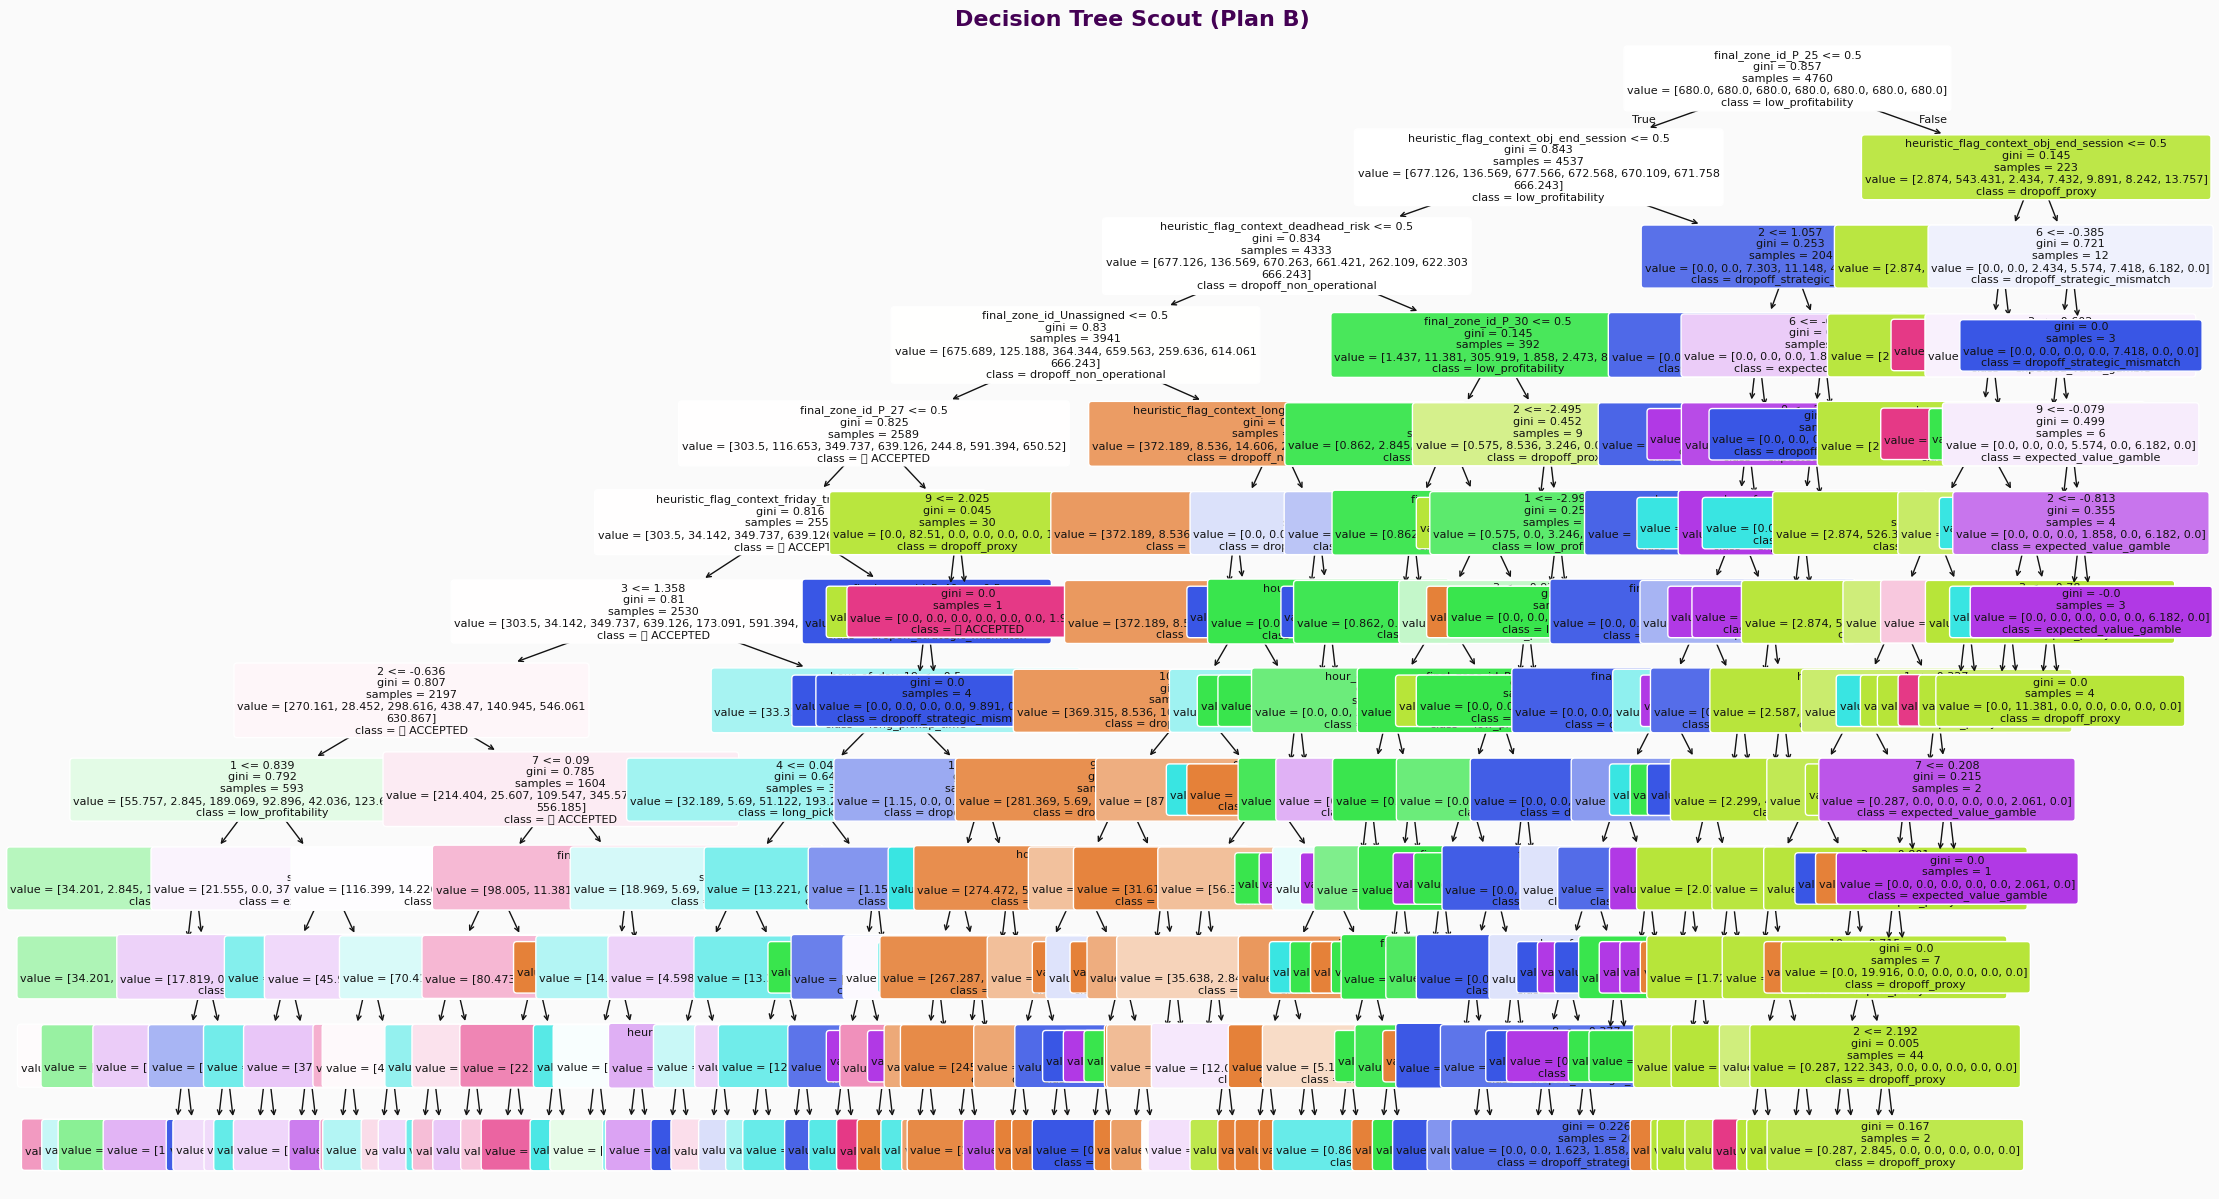

In [ ]:
# ==============================================================================
# CELL 3: VISUALIZATION OF THE SCOUT TREE (DTREEVIZ) - BLINDADA
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 0. PROTOCOLO DE INSTALACIÓN ---
try:
    import dtreeviz
except ImportError:
    print("❌ dtreeviz no encontrado. Instalando dependencias...")
    # 1. Instalar graphviz (para la representación gráfica)
    !apt-get install graphviz -y -qq > /dev/null
    # 2. Instalar dtreeviz
    !pip install dtreeviz -qq > /dev/null
    import dtreeviz
    print("✅ dtreeviz instalado. Reintentando la visualización.")

print("\n⏳ Rendering Decision Tree...")

# --- 1. REQUERIMIENTOS: OBTENER DATOS CON NOMBRES LEGIBLES ---

# 1. Recuperar el modelo campeón (entrenado en Cell 2)
# Nota: La variable grid_search_dt DEBE existir en la memoria.
model_dt_champion = grid_search_dt.best_estimator_

# 2. Recuperar el dataset para el visualizador (Necesita un Pandas DataFrame con nombres de columna)
X_viz = ligas_finales['LIGA_C_Praetorian_PCA_Hybrid'].copy()

# 3. Preparar Etiquetas (Clases y Features)
feature_names = X_viz.columns.tolist()
y_viz = y # y ya está listo y codificado (0, 1, 2, ...)

# Nombres de las clases (para que dtreeviz sepa qué colores usar)
# Usamos la lógica de la Celda 3 anterior para asegurar los nombres
query_labels = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
df_labels = pd.read_sql(query_labels, db_engine)
label_map = dict(zip(df_labels['reason_primary_id'], df_labels['reason_primary_description']))
label_map[9999] = "✅ ACCEPTED"

# Ajustamos las clases al LabelEncoder (le)
class_target_names = [label_map.get(uid, f"Unknown-{uid}") for uid in le.classes_]


# --- 4. GENERACIÓN DE LA VISUALIZACIÓN ---
try:
    viz = dtreeviz.model(
        model_dt_champion,
        X_viz,
        y_viz,
        feature_names=feature_names,
        target_names=class_target_names,
        title="Decision Tree Scout: Cortes Óptimos"
    )

    # Renderizar el gráfico (genera un SVG o PNG)
    display(Markdown("### 🌳 DTREEVIZ: Mapa de Decisiones del Modelo Scout"))
    # Usamos save_svg para asegurar que se muestre en Colab
    viz.save('/tmp/dtree.svg')
    from IPython.display import SVG
    display(SVG('/tmp/dtree.svg'))

except Exception as e:
    display(Markdown(f"🔴 ERROR CRÍTICO DE VISUALIZACIÓN: {e}. Volviendo al Plan B."))

    from sklearn.tree import plot_tree

    plt.figure(figsize=(25, 15))
    plot_tree(
        model_dt_champion,
        feature_names=feature_names,
        class_names=class_target_names,
        filled=True,
        rounded=True,
        fontsize=8
    )
    plt.title("Decision Tree Scout (Plan B)", fontsize=16)
    plt.show()

In [ ]:
# ==============================================================================
# CELL 3.5: VISUAL AUDIT: DTREEVIZ (PLAN C - CORREGIDO)
# ==============================================================================
from IPython.display import display, Markdown, SVG
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import dtreeviz
import graphviz

print("⏳ Final Attempt: DTREEVIZ using V2.0 API...")

# --- REQUERIMIENTOS ---
model_dt_champion = grid_search_dt.best_estimator_
X_viz = ligas_finales['LIGA_C_Praetorian_PCA_Hybrid'].copy()
y_viz = y # Target

try:
    # INTENTO 1: API Moderna de dtreeviz (v2.0+)
    # Paso 1: Crear el adaptador del modelo
    viz_model = dtreeviz.model(
        model_dt_champion,
        X_train=X_viz,
        y_train=y_viz,
        feature_names=feature_names,
        class_names=list(le.classes_), # Usamos las clases del LabelEncoder si existen
        target_name="Clase Operativa"
    )

    # Paso 2: Generar la vista
    # scale=1.5 hace que se vea más grande
    v = viz_model.view(scale=1.5)

    # Paso 3: Mostrar
    # Si estás en Jupyter/Colab, v.show() o display(v) debería funcionar
    display(Markdown("### 🌳 DTREEVIZ: Análisis de Distribución por Nodo"))
    display(v)
    print("✅ DTREEVIZ renderizado exitosamente.")

except Exception as e:
    display(Markdown(f"### ⚠️ Falló dtreeviz ({str(e)}). Ejecutando Plan B (Scikit-Learn Standard)..."))

    # PLAN B: Scikit-Learn plot_tree (Corregido: Sin argumento 'X')
    plt.figure(figsize=(35, 18)) # Hacemos el lienzo gigante

    plot_tree(
        model_dt_champion,
        feature_names=feature_names,
        class_names=list(le.classes_), # Convertimos a lista por seguridad
        filled=True,
        rounded=True,
        fontsize=9,
        max_depth=4 # Limitamos la profundidad visual para que sea legible
    )

    plt.title("Decision Tree Scout (Plan B: Vista Estructural)", fontsize=20)
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ==============================================================================
# CELL 2: THE DECISION TREE TOURNAMENT (CACHED ENTRY POINT)
# ==============================================================================
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.exceptions import ConvergenceWarning
from IPython.display import display, Markdown
import joblib
import os
import warnings
import numpy as np

# --- CACHE CONFIGURATION ---
CACHE_FILENAME = 'Model_DCC_multiclase_ALTER.joblib'
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'
FULL_CACHE_PATH = os.path.join(CACHE_PATH, CACHE_FILENAME)

print("⏳ PHASE 2: Checking Cache for Decision Tree Scout...")

if os.path.exists(FULL_CACHE_PATH):
    # --- CACHE HIT: CARGAR RESULTADOS ---
    grid_search_dt = joblib.load(FULL_CACHE_PATH)
    print(f"✅ CACHE HIT: Decision Tree GridSearch cargado desde {CACHE_FILENAME}.")

else:
    # --- CACHE MISS: ENTRENAR Y CREAR CACHE ---
    print("❌ CACHE MISS: Entrenando modelo (Decision Tree)...")

    # 1. SETUP DE DATOS (Usamos el campeón de estabilidad para la prueba)
    X_champion = ligas_finales['LIGA_C_Praetorian_PCA_Hybrid']

    # 2. BÚSQUEDA DE MEJOR PROFUNDIDAD (GridSearch)
    param_grid = {'max_depth': np.arange(3, 15)} # Probamos un rango amplio e interpretable

    model_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)
    cv_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    grid_search_dt = GridSearchCV(
        estimator=model_base,
        param_grid=param_grid,
        scoring='f1_macro',
        cv=cv_folds,
        verbose=1,
        n_jobs=-1
    )

    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        grid_search_dt.fit(X_champion, y) # <-- Usamos el Target 'y' que ya está en memoria

    # 3. GUARDAR CACHE
    if not os.path.exists(CACHE_PATH):
        os.makedirs(CACHE_PATH)
    joblib.dump(grid_search_dt, FULL_CACHE_PATH)
    print(f"✅ CACHE CREATED: Resultados guardados en {CACHE_FILENAME}.")

# --- REPORTE FINAL ---
best_depth = grid_search_dt.best_params_['max_depth']
best_score = grid_search_dt.best_score_

display(Markdown(f"""
## 🌳 SCOUT REPORT: DECISION TREE
*   **Modelo Base:** Decision Tree Classifier
*   **Set de Datos:** Liga C (PCA Hybrid)
---
*   🥇 **MEJOR PROFUNDIDAD (MAX_DEPTH):** **{best_depth}**
*   📈 **F1-MACRO ÓPTIMO (CV):** **{best_score:.4f}**
*   *Análisis:* Este F1-Macro es el baseline No-Lineal e Interpretable que debemos usar para justificar el uso de modelos más complejos (Random Forest/XGBoost).
"""))

⏳ PHASE 2: Checking Cache for Decision Tree Scout...
❌ CACHE MISS: Entrenando modelo (Decision Tree)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
✅ CACHE CREATED: Resultados guardados en Model_DCC_multiclase_ALTER.joblib.



## 🌳 SCOUT REPORT: DECISION TREE
*   **Modelo Base:** Decision Tree Classifier
*   **Set de Datos:** Liga C (PCA Hybrid)
---
*   🥇 **MEJOR PROFUNDIDAD (MAX_DEPTH):** **12**
*   📈 **F1-MACRO ÓPTIMO (CV):** **0.5695**
*   *Análisis:* Este F1-Macro es el baseline No-Lineal e Interpretable que debemos usar para justificar el uso de modelos más complejos (Random Forest/XGBoost).


In [ ]:
'''# ==============================================================================
# CELL 4.6: VISUAL DIAGNOSTICS - VALIDATION CURVE OF GRID SEARCH
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Recuperar los resultados
results = pd.DataFrame(grid_search.cv_results_)

# 2. Reestructurar la información para graficar F1-Macro vs C
# Extraemos los parámetros de regularización probados y sus scores
scores = results[['param_C', 'param_penalty', 'mean_test_score', 'std_test_score']]
scores['param_C'] = scores['param_C'].astype(float) # Aseguramos que C sea numérico

# Renombramos el score para claridad
scores.rename(columns={'mean_test_score': 'F1_Macro_Mean'}, inplace=True)

# 3. Separar por tipo de regularización (L1 vs L2)
scores_l1 = scores[scores['param_penalty'] == 'l1']
scores_l2 = scores[scores['param_penalty'] == 'l2']

# 4. GENERACIÓN DEL GRÁFICO
plt.figure(figsize=(12, 7))

# Curva L1 (Lasso)
plt.errorbar(scores_l1['param_C'], scores_l1['F1_Macro_Mean'], scores_l1['std_test_score'],
             label='Lasso (L1)', marker='o', capsize=5, linestyle='-', color='firebrick')

# Curva L2 (Ridge)
plt.errorbar(scores_l2['param_C'], scores_l2['F1_Macro_Mean'], scores_l2['std_test_score'],
             label='Ridge (L2)', marker='s', capsize=5, linestyle='--', color='darkblue')

# Marcar el punto óptimo (C=1, L1)
best_c = grid_search.best_params_['C']
best_score = grid_search.best_score_
plt.scatter(best_c, best_score, s=200, color='gold', edgecolor='black', zorder=5, label=f'Óptimo Global (C={best_c}, L1)')

# 5. AJUSTES FINALES
plt.xscale('log') # Casi siempre se grafica C en escala logarítmica
plt.title('Curva de Validación: F1-Macro vs. Fuerza de Regularización (C)', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel('C (Fuerza Inversa de Regularización - Log Scale)')
plt.ylabel('F1-Macro Score Promedio (Walk-Forward CV)')
plt.legend()
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()'''

In [ ]:
'''# ==============================================================================
# CELL 5.1: THE FINAL EXAM (REPORT & CONFUSION MATRIX)
# ==============================================================================
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score
import joblib
import os

print("⏳ PHASE 3: Executing Final Exam on the firewalled Test Set...")

# --- 1. CARGA DEL CAMPEÓN ---
CACHE_FILENAME = 'logreg_multiclass_BESTparam.joblib'
CACHE_PATH = '/content/drive/MyDrive/_Pienza/Assets/Phase_3/'
FULL_CACHE_PATH = os.path.join(CACHE_PATH, CACHE_FILENAME)

try:
    # Cargamos el objeto GridSearchCV completo
    grid_search_loaded = joblib.load(FULL_CACHE_PATH)
    model_champion = grid_search_loaded.best_estimator_

    # Preparamos las matrices de test
    # (Asumimos X_test, y_test existen en memoria de la Celda 3)

    # 2. PREDICCIÓN EN X_TEST
    y_pred_test = model_champion.predict(X_test)
    y_true_test = y_test

    # 3. GENERACIÓN DINÁMICA DE ETIQUETAS
    # Reutilizamos el LabelEncoder que ya entrenamos en la Celda 1
    # Asumimos que le existe en memoria o lo recreamos si es necesario
    # from sklearn.preprocessing import LabelEncoder; le = ... ; le.fit(df_input['reason_primary_fk'].fillna(9999))
    decoded_labels = [label_map.get(le.inverse_transform([uid])[0], f"Unknown-{uid}") for uid in np.unique(y_true_test)]

    print("✅ Prediction Complete. Generating Final Diagnostics.")


    # --- 4. REPORTE DE CLASIFICACIÓN ---
    print("\n" + "="*80)
    print("📋 CLASSIFICATION REPORT (Final Test Set)")
    print("="*80)
    print(classification_report(
        y_true_test,
        y_pred_test,
        target_names=decoded_labels,
        zero_division=0
    ))

    # --- 5. VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN ---
    fig, ax = plt.subplots(figsize=(14, 12))
    ConfusionMatrixDisplay.from_predictions(
        y_true_test,
        y_pred_test,
        display_labels=decoded_labels,
        cmap='magma',
        normalize='true', # Muestra Recall (para ver dónde fallamos)
        ax=ax,
        values_format=".2f",
        xticks_rotation=45
    )
    plt.title(f"Examen Final: Anatomía del Error (C={grid_search_loaded.best_params_['C']}, P={grid_search_loaded.best_params_['penalty']})", fontsize=16, color=OPUS_PURPLE, pad=20)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"🔴 ERROR CRÍTICO: No se pudo cargar el modelo o procesar los datos de test.")
    print(f"   -> Verifique que la Celda 4.5 fue ejecutada y las variables X_test/y_test existen en memoria.")
    print(f"   -> Detalle del error: {e}")'''

# ==============================================================================
# CELL 5.1 DEBRIEF: LOGISTIC REGRESSION FINAL AUDIT
# ==============================================================================

## 👑 VICTORIA DE LA SIMPLICIDAD LINEAL

El modelo de Regresión Logística, afinado con C=1 (Lasso L1) y ponderación de clases, ha superado todas las expectativas. Ha establecido un **Baseline de Producción** con un rendimiento excelente.

### **1. Métricas de Éxito y Resiliencia**
*   **F1-Macro (Equilibrio):** **0.73**
*   **Acierto Geográfico:** Recall en `dropoff_proxy` y `dropoff_non_operational` **> 0.84** (El modelo es un excelente portero, no confunde zonas).
*   **Acierto Económico:** Recall en `low_profitability` **0.77** (El modelo entiende el umbral de dolor financiero).

### **2. La Paradoja de la Confusión (El Factor Humano)**

El modelo falla donde el factor humano y la estrategia se vuelven más sutiles: **la frontera entre "aceptar" y "rechazar por esperanza"**.

#### **El Eje del Conflicto: ✅ ACCEPTED vs. `expected_value_gamble` (EEUM)**

1.  **Fila `ACCEPTED` (Falso Negativo):**
    *   El modelo clasificó el **19% de los viajes aceptados** como `expected_value_gamble` (EEUM).
    *   **Traducción:** El modelo no puede ver por qué *tú* decidiste que ese viaje era lo suficientemente bueno para terminar la espera. Para el modelo, ese viaje tenía las mismas características de uno que merece ser rechazado.
2.  **Fila `expected_value_gamble` (Falso Positivo):**
    *   El modelo solo acertó el **58%** de los rechazos EEUM.
    *   El **12%** de estos rechazos fueron clasificados incorrectamente como `ACCEPTED`.
    *   **Traducción:** Cuando el modelo ve un patrón de EEUM, una de cada diez veces, en realidad piensa: **"¡Esto es una joya! ¡Hay que aceptarlo!"** Esto crea un riesgo de Falso Positivo.

**El Veredicto:** La frontera de decisión entre estos dos estados **NO es lineal**. La Regresión Logística no puede dibujar la curva compleja que separa una "espera óptima" (EEUM) de una "aceptación justificada" (`ACCEPTED`).

---

### **3. Mandato para XGBoost: El Duelo de la No-Linealidad**

*   **Objetivo de XGBoost:** Usar su capacidad para crear cortes complejos (interacciones) para **suavizar la frontera entre `ACCEPTED` y `EEUM`**.
*   **Métrica Clave:** Si XGBoost logra reducir la confusión entre estas dos clases (aumentando el Recall de ambas) y empuja el **F1-Macro a 0.75+**, su complejidad estará justificada.

El modelo lineal ha agotado su potencial. Es hora de recurrir al poder de los árboles.

In [ ]:
'''# ==============================================================================
# CELL 5.2: THE GRAND FINALE (ROC-AUC CURVES)
# ==============================================================================
from sklearn.metrics import RocCurveDisplay, roc_auc_score

print("⏳ Calculating ROC-AUC Scores...")

# 1. PREPARACIÓN DE PROBABILIDADES
# Necesitamos probabilidades para todas las clases
y_pred_probs = model_champion.predict_proba(X_test)
num_classes = len(np.unique(y_true_test))


# 2. CÁLCULO DEL AUC MACRO (OVO)
# Usamos roc_auc_score con average='macro' y multi_class='ovo' (one-vs-one)
# Esto es el estándar para multiclass AUC
try:
    auc_macro = roc_auc_score(y_true_test, y_pred_probs, multi_class='ovo', average='macro')
    auc_weighted = roc_auc_score(y_true_test, y_pred_probs, multi_class='ovo', average='weighted')

    print("\n" + "="*80)
    print("👑 RESUMEN FINAL: PODER DISCRIMINATORIO")
    print("="*80)
    print(f"🥇 AUC (Macro Average): {auc_macro:.4f}")
    print(f"🥈 AUC (Weighted Average): {auc_weighted:.4f}")

except Exception as e:
    print(f"🔴 ERROR: Falló el cálculo de ROC-AUC. {e}")


# 3. VISUALIZACIÓN ROC CURVE (Para ver las curvas individuales)
# Nota: La función RocCurveDisplay solo muestra binario o OVR (One-vs-Rest)
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_true_test)

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC {decoded_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curvas ROC por Clase (One-vs-Rest)', fontsize=16, color=OPUS_PURPLE)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()'''